# Experiment 2 — Baseline Comparison

Per `docs/research_spec.md` §4, Experiment 2 is "the actual first real test":
does the learned `alpha` recover `rho` any better, faster (fewer samples),
or more robustly (under jump contamination) than a **trivial** baseline —
realized cross-sectional correlation computed directly on the data, no NN
involved?

This notebook loads the results already produced by
`experiments/experiment2a_sample_efficiency.py` and
`experiments/experiment2b_jump_robustness.py` and walks through what they
show. Full write-up: `results/experiment2_findings.md`.

**Headline result: the two-line correlation baseline matches or beats
`alpha` on both axes tested.** That's the negative result the spec
explicitly flagged as worth taking seriously (§6, criterion #2) — not a
failure of this notebook or the experiment, but the actual finding.


In [1]:
import sys
sys.path.insert(0, "..")

import csv
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.baseline import realized_corr_estimate

%matplotlib inline

def load_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))


## The baseline, in full

This is the entire competitor `alpha` is being measured against -- pool
every (path, timestep) observation into one sample, compute one correlation
matrix, average the off-diagonal entries. No training, no randomness beyond
the data itself, sub-second to run.


In [2]:
import inspect
print(inspect.getsource(realized_corr_estimate))


def realized_corr_estimate(x: torch.Tensor) -> float:
    """Pooled realized cross-sectional correlation.

    x: (n_paths, n_steps, n_assets) returns (same tensor the model trains
    on). Pools all (path, timestep) observations into one sample before
    computing the correlation matrix -- valid because paths are independent
    draws of the same cross-sectional structure and returns are i.i.d. over
    time, so this uses the full data budget rather than averaging noisier
    per-path estimates.

    Returns the mean off-diagonal entry of the correlation matrix, on the
    same footing as `JumpDiffusionGenerator.realized_cross_sectional_corr`.
    """
    arr = x.reshape(-1, x.shape[-1]).numpy()  # (n_paths * n_steps, n_assets)
    corr = np.corrcoef(arr, rowvar=False)
    n = corr.shape[0]
    return float(corr[np.triu_indices(n, k=1)].mean())



## 2a — Sample efficiency

Question: does `alpha` need less data than correlation to recover `rho`
equally well? Both estimators see the exact same generated panel at each
point -- same tensor, not separately-drawn samples -- so any gap is about
the estimator, not the data.

`medium` reuses Experiment 1's already-trained alpha values at the same
config (30 paths x 300 steps) rather than retraining.


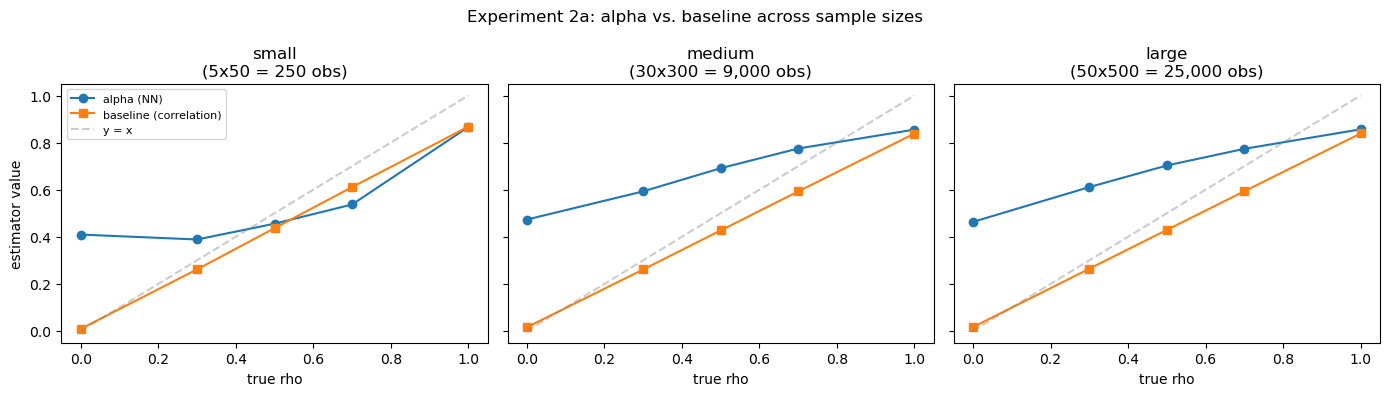

In [3]:
rows = load_csv("../results/experiment2a_sample_efficiency.csv")
sizes = ["small", "medium", "large"]
labels = {
    "small": "small\n(5x50 = 250 obs)",
    "medium": "medium\n(30x300 = 9,000 obs)",
    "large": "large\n(50x500 = 25,000 obs)",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, size in zip(axes, sizes):
    sub = [r for r in rows if r["sample_size"] == size]
    rho = [float(r["rho"]) for r in sub]
    alpha = [float(r["alpha"]) for r in sub]
    baseline = [float(r["baseline_corr"]) for r in sub]
    ax.plot(rho, alpha, "o-", label="alpha (NN)", color="C0")
    ax.plot(rho, baseline, "s-", label="baseline (correlation)", color="C1")
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.4, label="y = x")
    ax.set_title(labels[size])
    ax.set_xlabel("true rho")
axes[0].set_ylabel("estimator value")
axes[0].legend(fontsize=8)
plt.suptitle("Experiment 2a: alpha vs. baseline across sample sizes")
plt.tight_layout()
plt.show()


In [4]:
summary = load_csv("../results/experiment2a_summary.csv")
print(f"{'sample_size':10s} {'panel':16s} {'alpha_r':>10s} {'baseline_r':>12s}  winner")
for r in summary:
    a, b = float(r["alpha_pearson_r"]), float(r["baseline_pearson_r"])
    panel = f"{r['n_paths']}x{r['n_steps']}"
    winner = "baseline" if b >= a else "alpha"
    print(f"{r['sample_size']:10s} {panel:16s} {a:10.4f} {b:12.4f}  {winner}")


sample_size panel               alpha_r   baseline_r  winner
small      5x50                 0.8660       1.0000  baseline
medium     30x300               0.9945       1.0000  baseline
large      50x500               0.9911       1.0000  baseline


**Baseline wins at every sample size, including the smallest one tested**
(5 paths x 50 steps -- just 250 observations per asset). It's already at
Pearson r ~ 1.000 there. Alpha needs an order of magnitude more data to even
approach that, and doesn't clearly improve further from medium to large --
consistent with training noise dominating over any real gain from more data
at this scale, not a clean sample-efficiency curve in alpha's favor.


## 2b — Robustness to jump contamination

Question: does `alpha` degrade less than correlation when jump noise
increases? `jump_coupling` (the systemic/idiosyncratic jump split) is held
fixed across both conditions -- only `jump_std` (jump *size* noise) changes,
3x higher in the `high_jump_noise` condition.


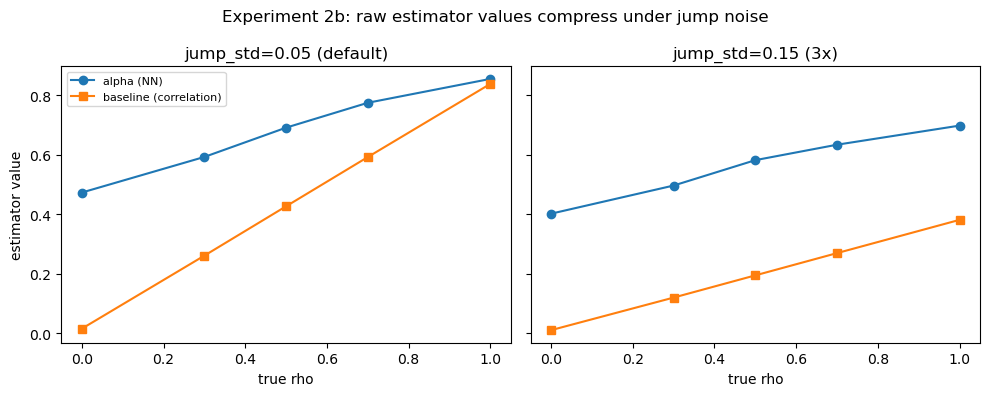

In [5]:
rows_b = load_csv("../results/experiment2b_jump_robustness.csv")
conditions = ["baseline_jumps", "high_jump_noise"]
cond_titles = {"baseline_jumps": "jump_std=0.05 (default)", "high_jump_noise": "jump_std=0.15 (3x)"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, cond in zip(axes, conditions):
    sub = [r for r in rows_b if r["condition"] == cond]
    rho = [float(r["rho"]) for r in sub]
    alpha = [float(r["alpha"]) for r in sub]
    baseline = [float(r["baseline_corr"]) for r in sub]
    ax.plot(rho, alpha, "o-", label="alpha (NN)", color="C0")
    ax.plot(rho, baseline, "s-", label="baseline (correlation)", color="C1")
    ax.set_title(cond_titles[cond])
    ax.set_xlabel("true rho")
axes[0].set_ylabel("estimator value")
axes[0].legend(fontsize=8)
plt.suptitle("Experiment 2b: raw estimator values compress under jump noise")
plt.tight_layout()
plt.show()


Notice both curves drop substantially in the high-noise panel (e.g. at
rho=1.0: baseline 0.838 -> 0.381, alpha 0.855 -> 0.698) -- added jump noise
inflates return variance without adding cross-sectional structure, which
dilutes any correlation-based measure, NN or not. The question that matters
for "robustness" is whether the *ranking* across rho survives, not the raw
level -- that's what Pearson r checks next.


In [6]:
summary_b = load_csv("../results/experiment2b_summary.csv")
print(f"{'condition':18s} {'jump_std':>9s} {'alpha_r':>10s} {'baseline_r':>12s}  winner")
for r in summary_b:
    a, b = float(r["alpha_pearson_r"]), float(r["baseline_pearson_r"])
    winner = "baseline" if b >= a else "alpha"
    print(f"{r['condition']:18s} {r['jump_std']:>9s} {a:10.4f} {b:12.4f}  {winner}")


condition           jump_std    alpha_r   baseline_r  winner
baseline_jumps          0.05     0.9945       1.0000  baseline
high_jump_noise         0.15     0.9920       1.0000  baseline


**Neither estimator wins here.** Both stay at rank-correlation ~0.99+ even
under 3x jump noise, and the baseline is (marginally) still ahead in both
conditions. Robustness to this kind of jump contamination is not a place
`alpha` differentiates itself from the two-line calculation.


## Verdict

Per the spec's own decision rule (§6, criterion #2): **the trivial baseline
matches or beats `alpha` on both axes tested, with far less compute** (no
training, no optimizer instability to debug, sub-second to run). This is
the negative result the spec flagged as the one to take seriously —
*"without this, the project is a more expensive way to compute something
correlation already gives you."*

This doesn't undo Experiment 1 — the gate does recover a real coupling
signal, the mechanism works — it says nothing tested *so far* makes the NN
worth its complexity over a two-line calculation. Two things this
experiment did **not** test, both flagged in the spec as the more likely
places for a real differentiator to show up:

1. **Disentangling diffusive coupling (rho) from jump coupling** —
   correlation conflates the two by construction; a jump-aware gate might
   not. `jump_coupling` was held fixed throughout this experiment.
2. **Non-linear / higher-order coupling structure** — this generator has a
   single linear common factor, exactly the regime correlation is best at.
   A structurally different generator (Experiment 4) or multi-factor stress
   test (Experiment 3) is where a nonlinear method would have room that
   correlation structurally can't reach.

Full reasoning: `results/experiment2_findings.md`.
